Data Collection:

In [1]:
import pandas as pd
df=pd.read_csv("netflix1.csv")
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


Data Cleaning:

In [2]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [4]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['date_added'] = pd.to_datetime(df['date_added'])

In [7]:
# Extract number
df['duration_num'] = df['duration'].str.extract('(\d+)')

# Convert to integer
df['duration_num'] = df['duration_num'].astype(int)

# Extract type (min / Season)
df['duration_type'] = df['duration'].str.extract('([a-zA-Z]+)')

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_151/1178127491.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)')


In [8]:
df['type'] = df['type'].map({'Movie': 0, 'TV Show': 1})

In [9]:
df['country'] = df['country'].str.strip()
df['listed_in'] = df['listed_in'].str.strip()

In [10]:
df['rating'] = df['rating'].astype('category').cat.codes

In [11]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [12]:
df.drop(['show_id'], axis=1, inplace=True)

In [13]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   type           8790 non-null   int64         
 1   title          8790 non-null   object        
 2   director       8790 non-null   object        
 3   country        8790 non-null   object        
 4   date_added     8790 non-null   datetime64[ns]
 5   release_year   8790 non-null   int64         
 6   rating         8790 non-null   int8          
 7   duration       8790 non-null   object        
 8   listed_in      8790 non-null   object        
 9   duration_num   8790 non-null   int64         
 10  duration_type  8790 non-null   object        
 11  year_added     8790 non-null   int32         
 12  month_added    8790 non-null   int32         
dtypes: datetime64[ns](1), int32(2), int64(3), int8(1), object(6)
memory usage: 764.1+ KB


,type,title,director,country,date_added,release_year,rating,duration,listed_in,duration_num,duration_type,year_added,month_added
0,0,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,4,90 min,Documentaries,90,min,2021,9
1,1,Ganglands,Julien Leclercq,France,2021-09-24,2021,8,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1,Season,2021,9
2,1,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,8,1 Season,"TV Dramas, TV Horror, TV Mysteries",1,Season,2021,9
3,0,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,9,91 min,"Children & Family Movies, Comedies",91,min,2021,9
4,0,Sankofa,Haile Gerima,United States,2021-09-24,1993,8,125 min,"Dramas, Independent Movies, International Movies",125,min,2021,9


EDA:

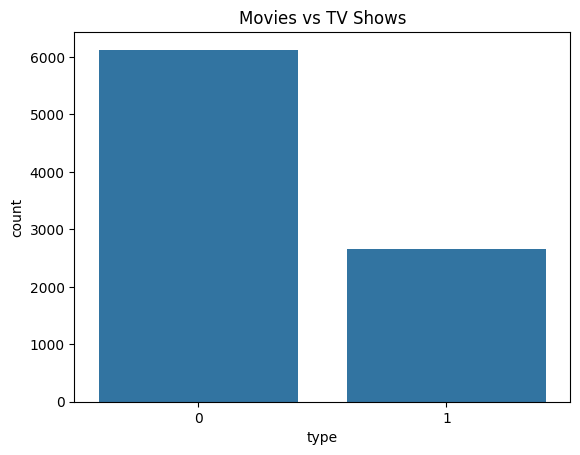

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

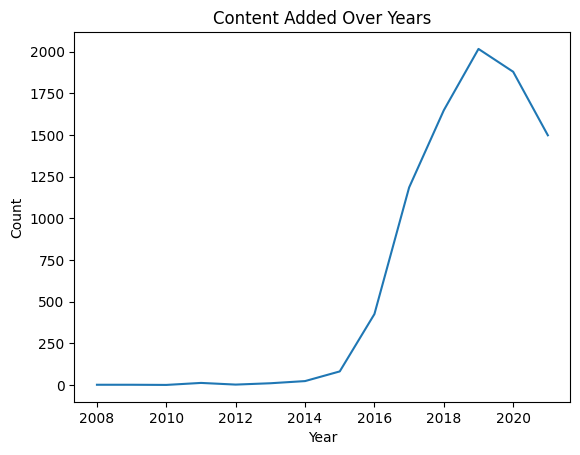

In [15]:
df['year_added'].value_counts().sort_index().plot()
plt.title("Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

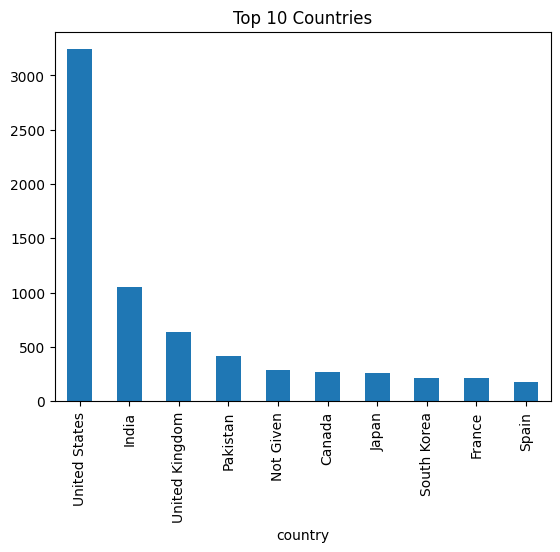

In [16]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries")
plt.show()

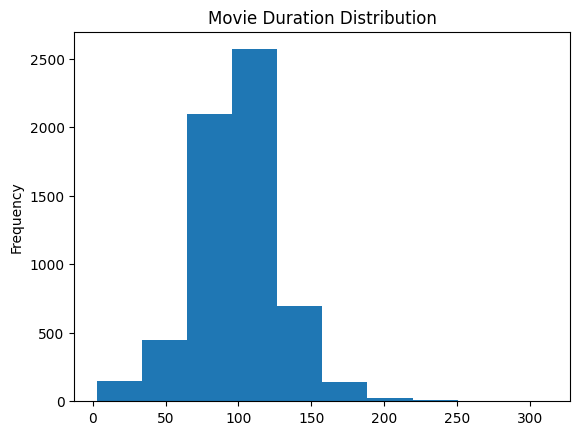

In [18]:
movies = df[df['duration_type'] == 'min']
movies['duration_num'].plot(kind='hist')
plt.title("Movie Duration Distribution")
plt.show()

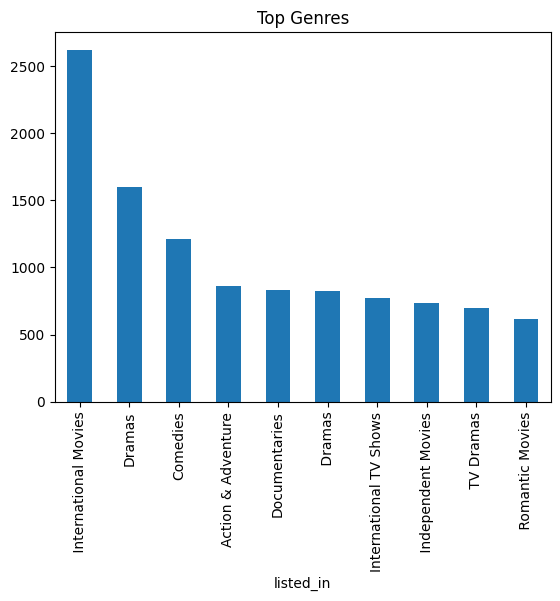

In [19]:
df['listed_in'].str.split(',').explode().value_counts().head(10).plot(kind='bar')
plt.title("Top Genres")
plt.show()